DATASET PREVIEW
   study_hours  attendance group_discussion  previous_test_score  \
0            8          60              Yes                   95   
1           16          77               No                   69   
2           12          74               No                   89   
3            9          99               No                   98   
4            8          72              Yes                   84   

  final_exam_pass  
0            Pass  
1            Pass  
2            Pass  
3            Pass  
4            Pass  


BASIC PROBABILITIES
P(Pass) = 0.5500
P(Attendance > 80%) = 0.4450
P(Group Discussion = Yes) = 0.5600


EMPIRICAL VS THEORETICAL PROBABILITY
Empirical Probability (Pass Exam) = 0.5500
Theoretical Probability (Weekend) = 0.2857


RANDOM VARIABLE X
   X    P(X=x)
0  0  0.091125
1  1  0.334125
2  2  0.408375
3  3  0.166375

Mean = 1.65
Variance = 0.7425


VENN DIAGRAM COUNTS
Only Study Hours > 10 : 52
Only Attendance > 80 : 51
Both : 38
Neither : 59


C

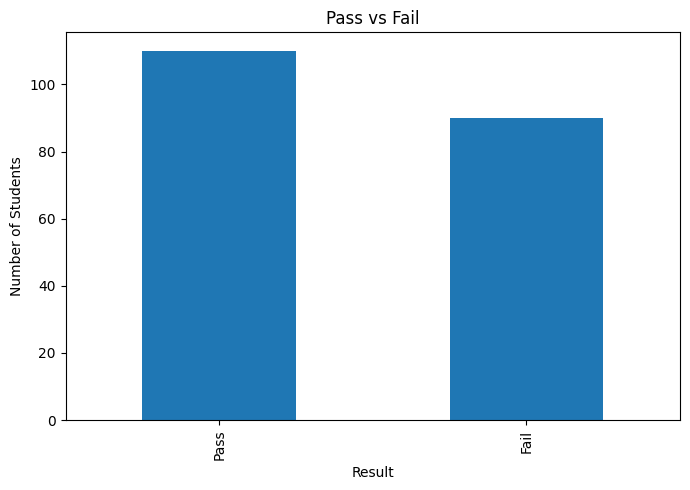

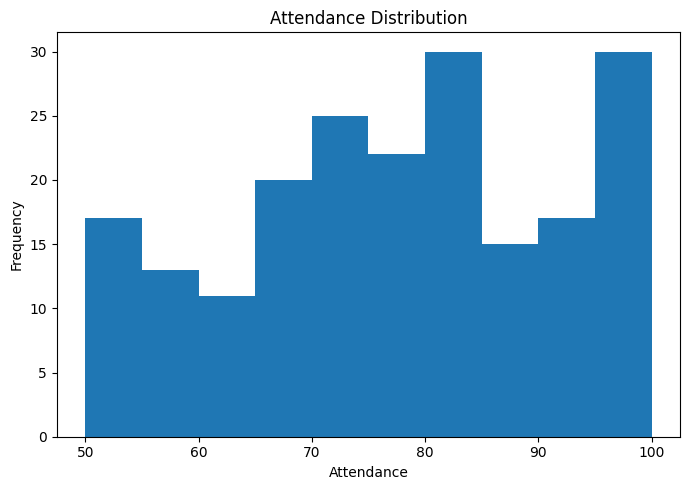

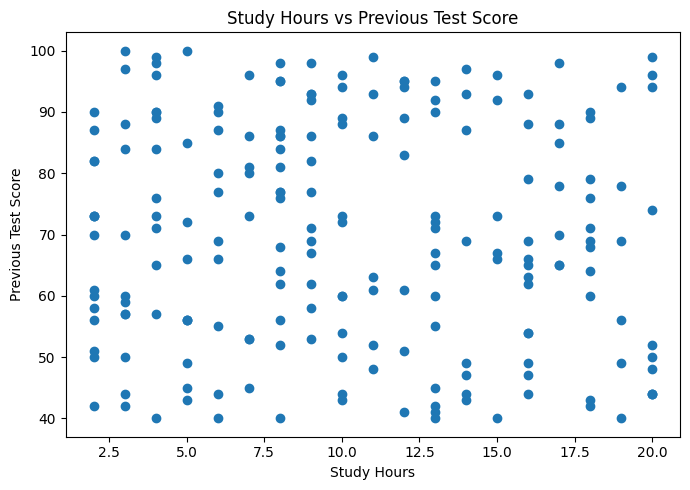

All PNG files saved successfully!


FINAL SUMMARY
1. Higher study hours improve success rate.
2. Attendance above 80% increases pass probability.
3. Group discussion participation improves performance.
4. Previous test scores strongly affect final results.
5. Conditional probability shows group participation
   increases the likelihood of passing.
6. Independence test identifies whether events
   are dependent or independent.
7. Bayes theorem predicts passing probability
   using attendance information.

Project Completed Successfully!


In [1]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import binom

# ---------------------------------------------------------
# 1. GENERATE DATASET (200 STUDENTS)
# ---------------------------------------------------------

np.random.seed(42)

n = 200

study_hours = np.random.randint(2, 21, n)
attendance = np.random.randint(50, 101, n)
group_discussion = np.random.choice(["Yes", "No"], n, p=[0.6, 0.4])
previous_test_score = np.random.randint(40, 101, n)

score = (
    0.25 * study_hours +
    0.30 * (attendance / 10) +
    0.35 * (previous_test_score / 10) +
    np.where(group_discussion == "Yes", 2, 0)
)

final_exam_pass = np.where(
    score >= np.percentile(score, 45),
    "Pass",
    "Fail"
)

df = pd.DataFrame({
    "study_hours": study_hours,
    "attendance": attendance,
    "group_discussion": group_discussion,
    "previous_test_score": previous_test_score,
    "final_exam_pass": final_exam_pass
})

print("=" * 60)
print("DATASET PREVIEW")
print("=" * 60)
print(df.head())


df.to_csv("expectation_decider_dataset.csv", index=False)

# ---------------------------------------------------------
# 2. BASIC PROBABILITY CALCULATIONS
# ---------------------------------------------------------

print("\n")
print("=" * 60)
print("BASIC PROBABILITIES")
print("=" * 60)

P_pass = (df["final_exam_pass"] == "Pass").mean()
P_high_attendance = (df["attendance"] > 80).mean()
P_group = (df["group_discussion"] == "Yes").mean()

print(f"P(Pass) = {P_pass:.4f}")
print(f"P(Attendance > 80%) = {P_high_attendance:.4f}")
print(f"P(Group Discussion = Yes) = {P_group:.4f}")

# ---------------------------------------------------------
# 3. EMPIRICAL VS THEORETICAL PROBABILITY
# ---------------------------------------------------------

print("\n")
print("=" * 60)
print("EMPIRICAL VS THEORETICAL PROBABILITY")
print("=" * 60)

empirical_probability = P_pass
theoretical_probability = 2 / 7

print(f"Empirical Probability (Pass Exam) = {empirical_probability:.4f}")
print(f"Theoretical Probability (Weekend) = {theoretical_probability:.4f}")

# ---------------------------------------------------------
# 4. RANDOM VARIABLE DISTRIBUTION
# ---------------------------------------------------------

print("\n")
print("=" * 60)
print("RANDOM VARIABLE X")
print("=" * 60)

p = P_pass
n_students = 3

distribution = pd.DataFrame({
    "X": range(4),
    "P(X=x)": [binom.pmf(x, n_students, p) for x in range(4)]
})

print(distribution)

mean_x = n_students * p
variance_x = n_students * p * (1 - p)

print("\nMean =", round(mean_x, 4))
print("Variance =", round(variance_x, 4))

# ---------------------------------------------------------
# 5. VENN DIAGRAM VALUES
# ---------------------------------------------------------

print("\n")
print("=" * 60)
print("VENN DIAGRAM COUNTS")
print("=" * 60)

A = df["study_hours"] > 10
B = df["attendance"] > 80

only_A = np.sum(A & ~B)
only_B = np.sum(~A & B)
both = np.sum(A & B)
neither = np.sum(~A & ~B)

print("Only Study Hours > 10 :", only_A)
print("Only Attendance > 80 :", only_B)
print("Both :", both)
print("Neither :", neither)

# ---------------------------------------------------------
# 6. CONTINGENCY TABLE
# ---------------------------------------------------------

print("\n")
print("=" * 60)
print("CONTINGENCY TABLE")
print("=" * 60)

contingency_table = pd.crosstab(
    df["group_discussion"],
    df["final_exam_pass"]
)

print(contingency_table)

joint_probability = len(
    df[
        (df["group_discussion"] == "Yes") &
        (df["final_exam_pass"] == "Pass")
    ]
) / len(df)

marginal_probability = len(
    df[df["final_exam_pass"] == "Pass"]
) / len(df)

conditional_probability = (
    len(
        df[
            (df["group_discussion"] == "Yes") &
            (df["final_exam_pass"] == "Pass")
        ]
    )
    /
    len(df[df["group_discussion"] == "Yes"])
)

print("\nJoint Probability P(Group AND Pass) =",
      round(joint_probability, 4))

print("Marginal Probability P(Pass) =",
      round(marginal_probability, 4))

print("Conditional Probability P(Pass | Group) =",
      round(conditional_probability, 4))

# ---------------------------------------------------------
# 7. INDEPENDENCE TEST
# ---------------------------------------------------------

print("\n")
print("=" * 60)
print("INDEPENDENCE TEST")
print("=" * 60)

left_side = joint_probability

right_side = (
    (df["group_discussion"] == "Yes").mean()
    *
    (df["final_exam_pass"] == "Pass").mean()
)

print("P(A ∩ B) =", round(left_side, 4))
print("P(A) * P(B) =", round(right_side, 4))

if abs(left_side - right_side) < 0.02:
    print("Events are Approximately Independent")
else:
    print("Events are Dependent")

# ---------------------------------------------------------
# 8. BAYES THEOREM
# ---------------------------------------------------------

print("\n")
print("=" * 60)
print("BAYES THEOREM")
print("=" * 60)

P_H_given_Pass = 0.70
P_H_given_Fail = 0.40
P_H = 0.60

P_Pass = (
    (P_H - P_H_given_Fail)
    /
    (P_H_given_Pass - P_H_given_Fail)
)

P_Pass_given_H = (
    P_H_given_Pass * P_Pass
) / P_H

print("P(Pass | High Attendance) =",
      round(P_Pass_given_H, 4))



# ---------------------------------------------------------
# 9. VISUALIZATION 1
# ---------------------------------------------------------

plt.figure(figsize=(7, 5))
df["final_exam_pass"].value_counts().plot(kind="bar")

plt.title("Pass vs Fail")
plt.xlabel("Result")
plt.ylabel("Number of Students")
plt.tight_layout()

# Save as PNG
plt.savefig("pass_vs_fail.png", dpi=300, bbox_inches="tight")

plt.show()

# ---------------------------------------------------------
# 10. VISUALIZATION 2
# ---------------------------------------------------------

plt.figure(figsize=(7, 5))
plt.hist(df["attendance"], bins=10)

plt.title("Attendance Distribution")
plt.xlabel("Attendance")
plt.ylabel("Frequency")
plt.tight_layout()

# Save as PNG
plt.savefig("attendance_distribution.png", dpi=300, bbox_inches="tight")

plt.show()

# ---------------------------------------------------------
# 11. VISUALIZATION 3
# ---------------------------------------------------------

plt.figure(figsize=(7, 5))
plt.scatter(
    df["study_hours"],
    df["previous_test_score"]
)

plt.title("Study Hours vs Previous Test Score")
plt.xlabel("Study Hours")
plt.ylabel("Previous Test Score")
plt.tight_layout()

# Save as PNG
plt.savefig("study_hours_vs_test_score.png", dpi=300, bbox_inches="tight")

plt.show()

print("All PNG files saved successfully!")

# ---------------------------------------------------------
# 12. FINAL SUMMARY
# ---------------------------------------------------------

print("\n")
print("=" * 60)
print("FINAL SUMMARY")
print("=" * 60)

print("1. Higher study hours improve success rate.")
print("2. Attendance above 80% increases pass probability.")
print("3. Group discussion participation improves performance.")
print("4. Previous test scores strongly affect final results.")
print("5. Conditional probability shows group participation")
print("   increases the likelihood of passing.")
print("6. Independence test identifies whether events")
print("   are dependent or independent.")
print("7. Bayes theorem predicts passing probability")
print("   using attendance information.")

print("\nProject Completed Successfully!")